In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
train_dir='Data_brain/Training'
test_dir='Data_brain/Testing'

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    zoom_range=0.3,
    shear_range=0.3,
    brightness_range=[0.7,1.3],
    horizontal_flip=True
)

In [7]:
# Data Loading 
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Class Labels:",train_data.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Class Labels: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.3),

    Dense(128,activation='relu'),
    Dense(4,activation='softmax')
])

from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6)

In [12]:
history=model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    batch_size=16,          
    callbacks=[es, lr]
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 693ms/step - accuracy: 0.5560 - loss: 1.1056 - val_accuracy: 0.2500 - val_loss: 3.5275 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 69s 490ms/step - accuracy: 0.6382 - loss: 0.8712 - val_accuracy: 0.3473 - val_loss: 1.7254 - learning_rate: 1.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 473ms/step - accuracy: 0.6743 - loss: 0.7857 - val_accuracy: 0.6170 - val_loss: 0.9291 - learning_rate: 1.0000e-04
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 69s 493ms/step - accuracy: 0.7074 - loss: 0.7130 - val_accuracy: 0.6786 - val_loss: 0.7702 - learning_rate: 1.0000e-04
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 480ms/step - accuracy: 0.7257 - loss: 0.6806 - val_accuracy: 0.7330 - val_loss: 0.6583 - learning_rate: 1.0000e-04
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 507ms/step - accuracy: 0.7417 - loss: 0.6276 - val_accuracy: 0.7911 - val_loss: 0.5353 - learning_rate: 1.0000e-04
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 50

In [13]:
# Model evaluate
test_gen=ImageDataGenerator(rescale=1./255)

test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_loss,test_acc=model.evaluate(test_data)
print("Test Accuracy:",test_acc)

Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7375 - loss: 1.1234
Test Accuracy: 0.737500011920929


In [14]:
X,y = next(test_data)         
preds = model.predict(X)       

for i in range(5):            
    print("Predicted:", np.argmax(preds[i]), "Actual:", np.argmax(y[i]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicted: 3 Actual: 3
Predicted: 3 Actual: 3
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 2 Actual: 2


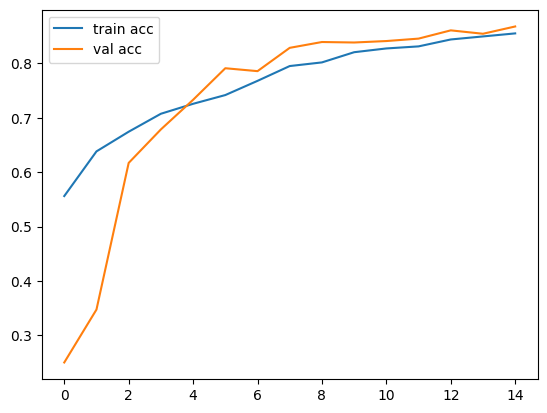

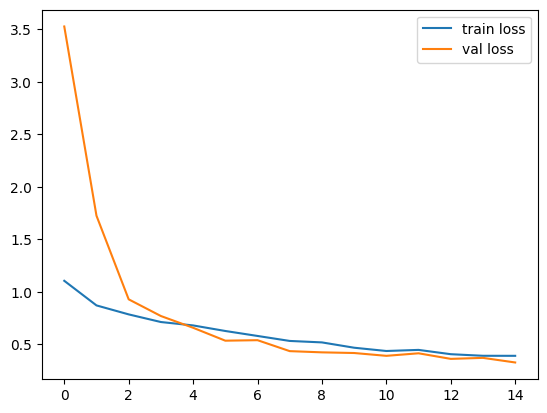

In [15]:
plt.plot(history.history['accuracy'],label='train acc')
plt.plot(history.history['val_accuracy'],label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step


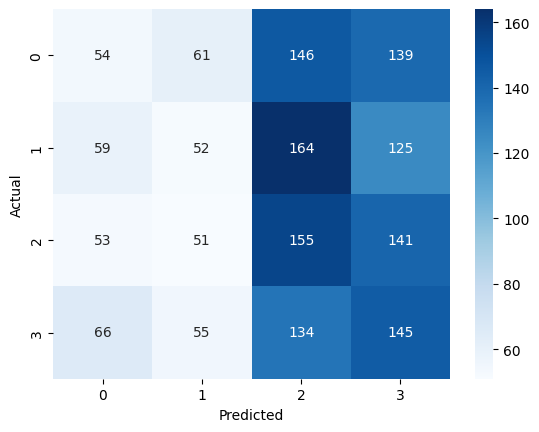

              precision    recall  f1-score   support

           0       0.23      0.14      0.17       400
           1       0.24      0.13      0.17       400
           2       0.26      0.39      0.31       400
           3       0.26      0.36      0.31       400

    accuracy                           0.25      1600
   macro avg       0.25      0.25      0.24      1600
weighted avg       0.25      0.25      0.24      1600



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Y_true = test_data.classes
Y_pred = model.predict(test_data)
Y_pred_classes = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(Y_true, Y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(Y_true, Y_pred_classes))


In [17]:
model.save("brain_tumor_model.keras")